In [ ]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats


In [ ]:
# cdmx data for comparison 
url = 'drive url'
output = 'cdmx_data.csv'
gdown.download(url, output, quiet=False)

df_raw = pd.read_csv(output)

Downloading...
From: To: /content/cdmx_data.csv
100%|██████████| 92.7k/92.7k [00:00<00:00, 7.40MB/s]


In [ ]:
df_raw.municipio.unique()

array(['Azcapotzalco', 'Coyoacán', 'Cuajimalpa de Morelos',
       'Gustavo A. Madero', 'Iztacalco', 'Iztapalapa',
       'La Magdalena Contreras', 'Milpa Alta', 'Álvaro Obregón',
       'Tláhuac', 'Tlalpan', 'Xochimilco', 'Benito Juárez', 'Cuauhtémoc',
       'Miguel Hidalgo', 'Venustiano Carranza'], dtype=object)

In [ ]:
df_alva = df_raw[df_raw.municipio == 'Álvaro Obregón']

In [ ]:
# datos oax

url = 'drive url'
output = 'pib_data.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: To: /content/pib_data.csv
100%|██████████| 5.72k/5.72k [00:00<00:00, 6.08MB/s]


'pib_data.csv'

In [ ]:
# datos de pib
quarterly_df = pd.read_csv('pib_data.csv')
quarterly_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   fecha               80 non-null     object 
 1   municipio           80 non-null     object 
 2   entidad_federativa  80 non-null     object 
 3   porc_pob            80 non-null     float64
 4   pibe                80 non-null     object 
 5   pib_mun             80 non-null     float64
dtypes: float64(2), object(4)
memory usage: 3.9+ KB


In [ ]:
quarterly_df.head()

,fecha,municipio,entidad_federativa,porc_pob,pibe,pib_mun
0,2004-03-31,Oaxaca de Juarez,OAX,0.065572,"210,757.2",13819.86196
1,2004-06-30,Oaxaca de Juarez,OAX,0.065572,"211,487.2",13867.73025
2,2004-09-30,Oaxaca de Juarez,OAX,0.065572,"213,136.2",13975.85845
3,2004-12-31,Oaxaca de Juarez,OAX,0.065572,"215,108.7",14105.20413
4,2005-03-31,Oaxaca de Juarez,OAX,0.065572,"213,677.2",14011.33510


In [ ]:
# datos de luz
url = 'drive url'
output = 'raw_data.csv'
gdown.download(url, output, quiet=False)

df_luz = pd.read_csv(output)
print(df_raw.head())


Downloading...
From: To: /content/raw_data.csv
100%|██████████| 35.3M/35.3M [00:00<00:00, 102MB/s]


        fecha     municipio entidad_federativa  porc_pob       pibe  \
0  2004-03-31  Azcapotzalco               CDMX   0.04845  2226949.7   
1  2004-06-30  Azcapotzalco               CDMX   0.04845  2234735.2   
2  2004-09-30  Azcapotzalco               CDMX   0.04845  2244809.2   
3  2004-12-31  Azcapotzalco               CDMX   0.04845  2260342.1   
4  2005-03-31  Azcapotzalco               CDMX   0.04845  2258091.6   

         pib_mun  
0  107895.004216  
1  108272.209213  
2  108760.291307  
3  109512.855369  
4  109403.819360  


# EDA PIB

In [ ]:
quarterly_df['fecha'] = pd.to_datetime(quarterly_df['fecha'])

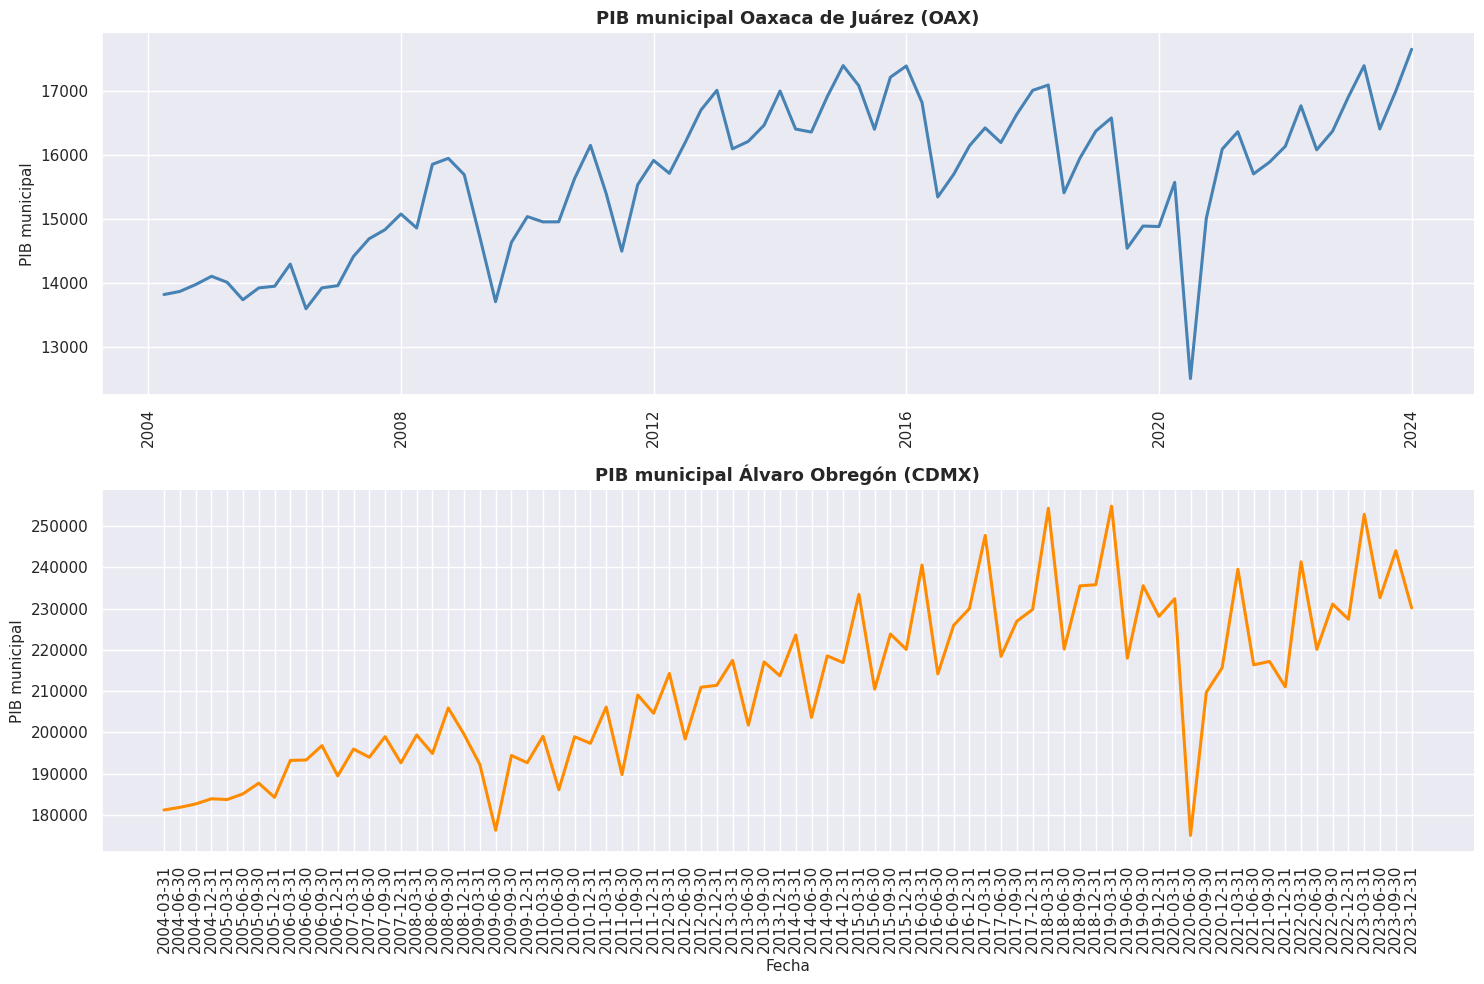

In [ ]:
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.lineplot(data=quarterly_df, x="fecha", y="pib_mun", color="steelblue", linewidth=2.2)
plt.title("PIB municipal Oaxaca de Juárez (OAX)", fontsize=13, fontweight="bold")
plt.ylabel("PIB municipal", fontsize=11)
plt.xlabel("")
plt.xticks(rotation=90)


plt.subplot(2, 1, 2)
sns.lineplot(data=df_alva, x="fecha", y="pib_mun", color="darkorange", linewidth=2.2)
plt.title("PIB municipal Álvaro Obregón (CDMX)", fontsize=13, fontweight="bold")
plt.ylabel("PIB municipal", fontsize=11)
plt.xlabel("Fecha", fontsize=11)
plt.xticks(rotation=90)


sns.despine()
plt.tight_layout()
plt.show()

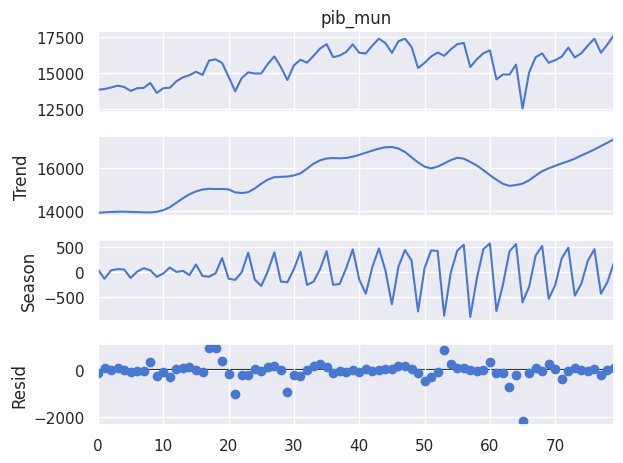

In [ ]:
from statsmodels.tsa.seasonal import STL

res = STL(quarterly_df['pib_mun'], period=4, robust=True).fit()
res.plot();

In [ ]:
from statsmodels.tsa.stattools import adfuller

residuals = res.resid
result = adfuller(residuals)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -6.694046582469391
p-value: 4.041552053416249e-09


In [ ]:
serie = res.trend

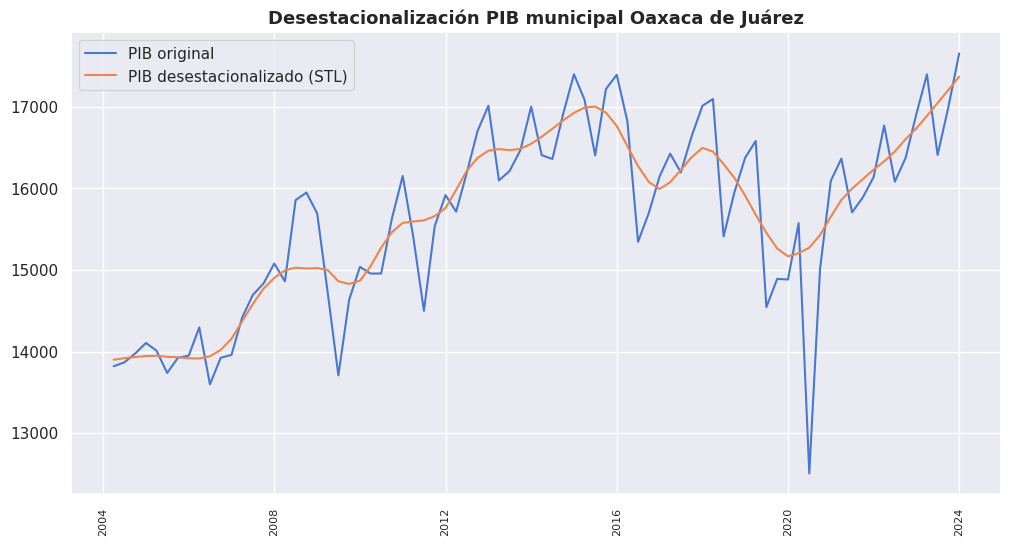

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(quarterly_df.fecha,quarterly_df.pib_mun,label='PIB original')
plt.plot(quarterly_df.fecha,res.trend,label='PIB desestacionalizado (STL)')
plt.legend()
plt.title('Desestacionalización PIB municipal Oaxaca de Juárez',fontsize=13, fontweight="bold")
plt.xticks(rotation=90, fontsize=8)
plt.show()

# Detrend serie PIB

In [ ]:
# serie de pib solo trend

n_cols = len(quarterly_df.columns[5:])
df_list_pib = []
municipios = quarterly_df['municipio'].unique()


#hacer trend por municipio
for municipio in municipios:

  # hacer trend por categoria
  df = quarterly_df[quarterly_df.municipio == municipio]
  lista_series = []

  for categoria in quarterly_df.columns[5:]:
    series = df[categoria]
    result = STL(quarterly_df['pib_mun'], period=4, robust=True).fit()
    categoria = result.trend  # extraer componente trend (mantiene NaNs)
    lista_series.append(categoria)

  df_no_trend = pd.DataFrame({
    'fecha': df.fecha,
    'municipio': df.municipio,
    'entidad_federativa': df.entidad_federativa,
    'porc_pob': df.porc_pob,
    'pibe': df.pibe,
    'pib_mun': lista_series[0].values
  })

  df_list_pib.append(df_no_trend)


df_trend_pib = pd.concat(df_list_pib, ignore_index=True)

In [ ]:
df_trend_pib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   fecha               80 non-null     datetime64[ns]
 1   municipio           80 non-null     object        
 2   entidad_federativa  80 non-null     object        
 3   porc_pob            80 non-null     float64       
 4   pibe                80 non-null     object        
 5   pib_mun             80 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(3)
memory usage: 3.9+ KB


# NTL

In [ ]:
df_oax = df_luz[df_luz.Municipio == 'oaxaca de juarez']

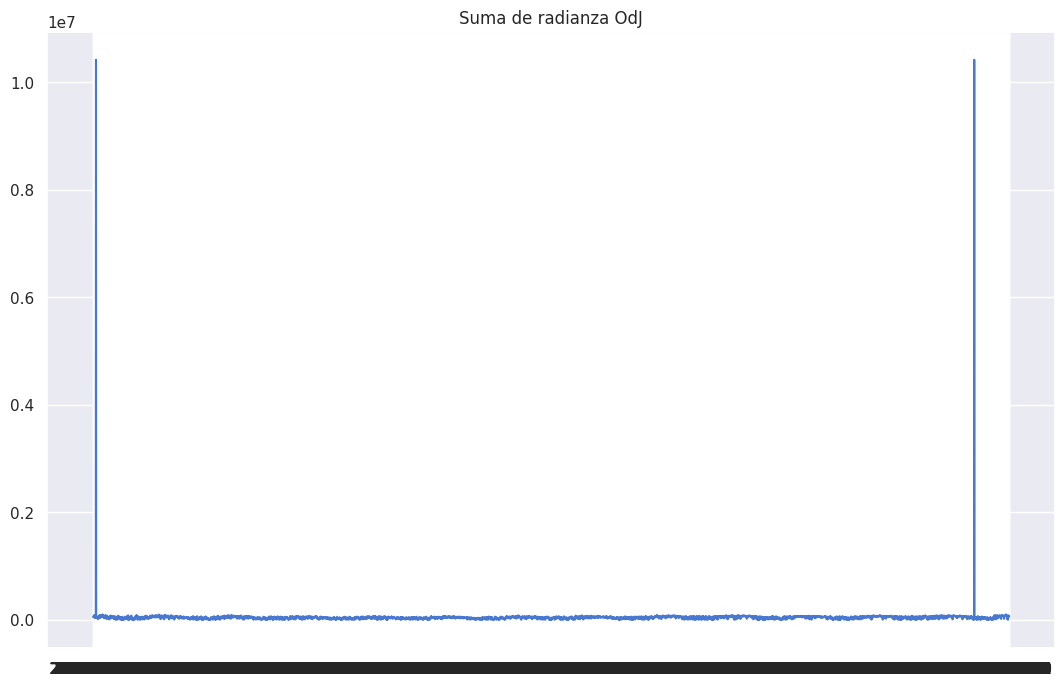

In [ ]:
import matplotlib.cm as cm

plt.figure(figsize=(13, 8))

series_features = df_oax.columns[3:]
plt.plot(df_oax.Fecha,df_oax.Suma_de_radianza)
plt.title('Suma de radianza OdJ')
plt.show()


In [ ]:
fechas_sospe = df_oax['Suma_de_radianza'].nlargest(2)
print(fechas_sospe)
rows_sospe = df_oax.loc[fechas_sospe.index]
display(rows_sospe)

340830    10420065.0
345309    10420065.0
Name: Suma_de_radianza, dtype: float64


,Fecha,Municipio,Cantidad_de_pixeles,Suma_de_radianza,Media_de_radianza,Desviacion_estandar_de_radianza,Maximo_de_radianza,Minimo_de_radianza,Percentil_25_de_radianza,Percentil_50_de_radianza,Percentil_75_de_radianza
340830,2012-02-02,oaxaca de juarez,159,10420065.0,65535.0,0.0,65535.0,65535.0,65535.0,65535.0,65535.0
345309,2024-06-17,oaxaca de juarez,159,10420065.0,65535.0,0.0,65535.0,65535.0,65535.0,65535.0,65535.0


In [ ]:
target_dates = [pd.Timestamp('2012-02-02'),pd.Timestamp('2024-06-17')]
df_oax['Fecha'] = pd.to_datetime(df_oax['Fecha'])

for target_date in target_dates:
    mask = df_oax['Fecha'] == target_date
    if not mask.any():
        continue

    outlier_index = df_oax.index[mask][0]
    idx_pos = df_oax.index.get_loc(outlier_index)

    for categoria in df_oax.columns[3:]:
        if idx_pos > 0 and idx_pos < len(df_oax) - 1:
            prev_val = df_oax.iloc[idx_pos - 1][categoria]
            next_val = df_oax.iloc[idx_pos + 1][categoria]
            replacement = np.nanmean([prev_val, next_val])
            df_oax.loc[outlier_index, categoria] = replacement


/tmp/ipython-input-1630272737.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oax['Fecha'] = pd.to_datetime(df_oax['Fecha'])


In [ ]:
fechas_sospe = df_oax['Suma_de_radianza'].nlargest(2)
print(fechas_sospe)

345471    101749.0
345470    101236.0
Name: Suma_de_radianza, dtype: float64


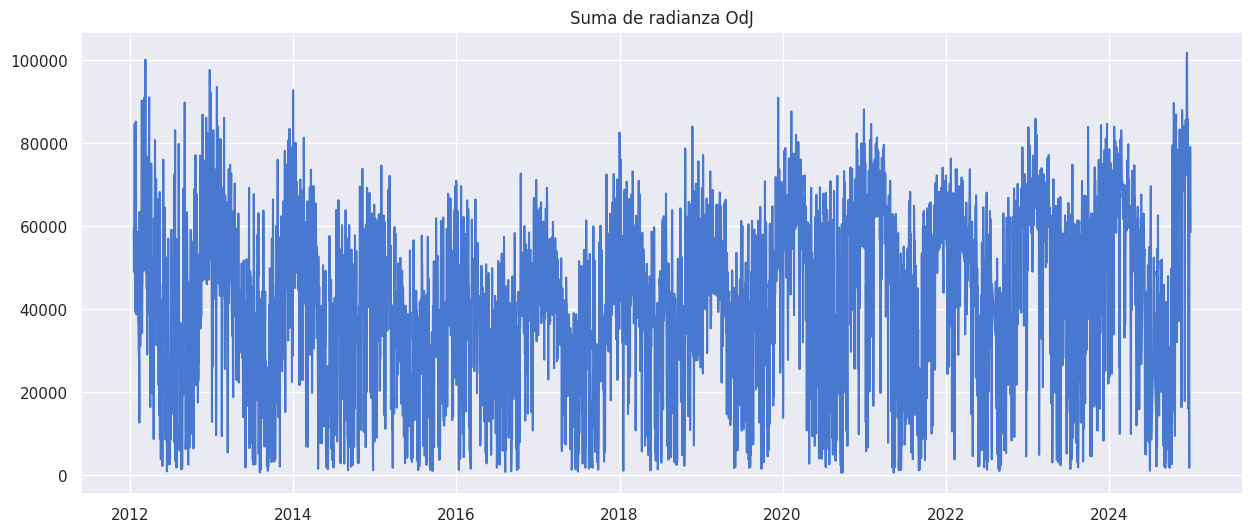

In [ ]:
plt.figure(figsize=(15, 6))
series_features = df_oax.columns[3:]
plt.plot(df_oax.Fecha,df_oax.Suma_de_radianza)
plt.title('Suma de radianza OdJ')
plt.show()

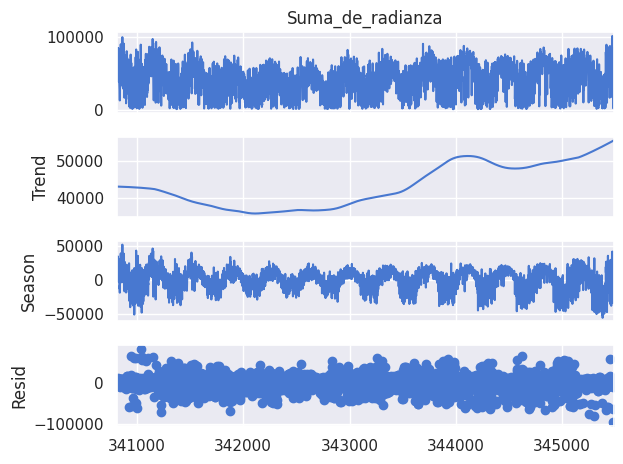

In [ ]:
res_luz = STL(df_oax['Suma_de_radianza'], period=365, robust=True).fit()
res_luz.plot();

In [ ]:
df_oax.columns[3:]

Index(['Suma_de_radianza', 'Media_de_radianza',
       'Desviacion_estandar_de_radianza', 'Maximo_de_radianza',
       'Minimo_de_radianza', 'Percentil_25_de_radianza',
       'Percentil_50_de_radianza', 'Percentil_75_de_radianza'],
      dtype='object')

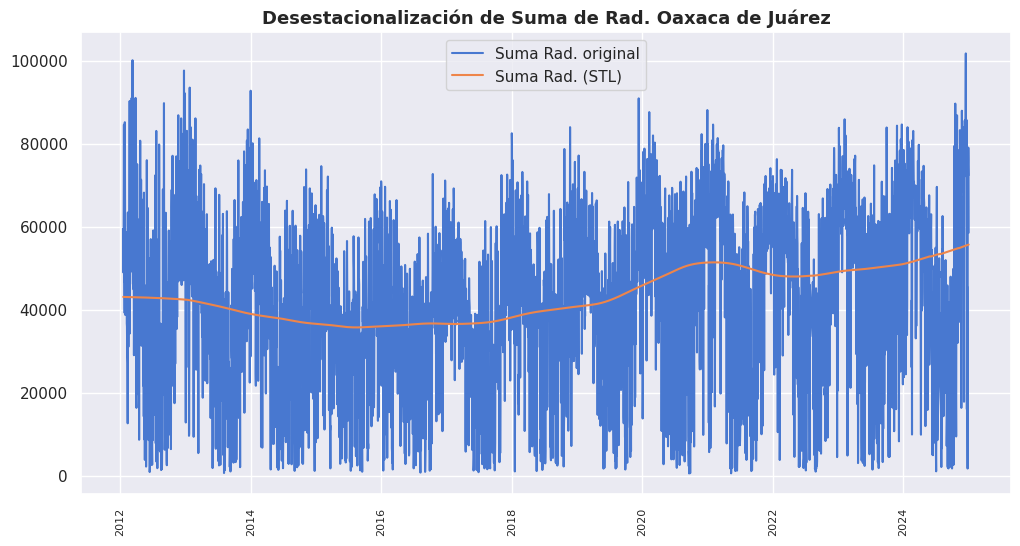

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(df_oax.Fecha,df_oax.Suma_de_radianza,label='Suma Rad. original')
plt.plot(df_oax.Fecha,res_luz.trend,label='Suma Rad. (STL)')
plt.legend()
plt.title('Desestacionalización de Suma de Rad. Oaxaca de Juárez',fontsize=13, fontweight="bold")
plt.xticks(rotation=90, fontsize=8)
plt.show()

# Detrend serie Luz

In [ ]:
n_cols = len(df_oax.columns[2:])

features = df_oax.columns[3:]
# hacer trend por categoria
lista_series = []
for categoria in features:
  series = df_oax[categoria]
  result = STL(series, period=365, robust=True).fit()
  detrended = result.trend
  lista_series.append(detrended)

df_trend = pd.DataFrame({
    'fecha': df_oax.Fecha,
    'municipio': df_oax.Municipio,
    'total_pixeles': df_oax.Cantidad_de_pixeles,
    'suma_rad_trend': lista_series[0].values,
    'media_rad_trend': lista_series[1].values,
    'std_rad_trend': lista_series[2].values,
    'max_rad_trend': lista_series[3].values,
    'min_rad_trend':lista_series[4].values,
    'p25_rad_trend': lista_series[5].values,
    'mediana_rad_trend': lista_series[6].values,
    'p75_rad_trend': lista_series[7].values
})


In [ ]:
len(lista_series[0])

4672

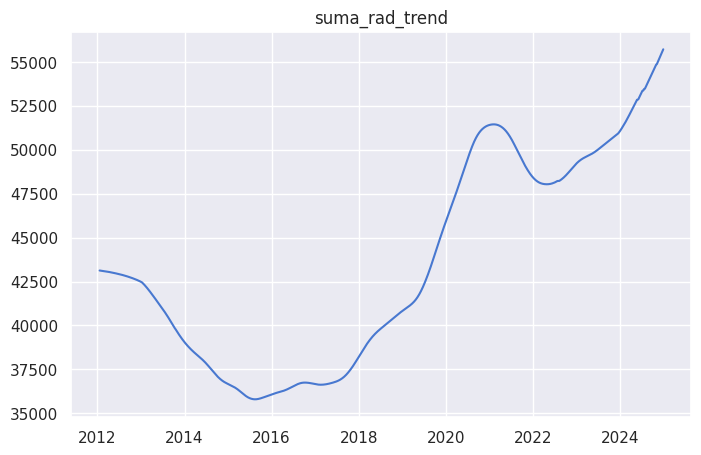

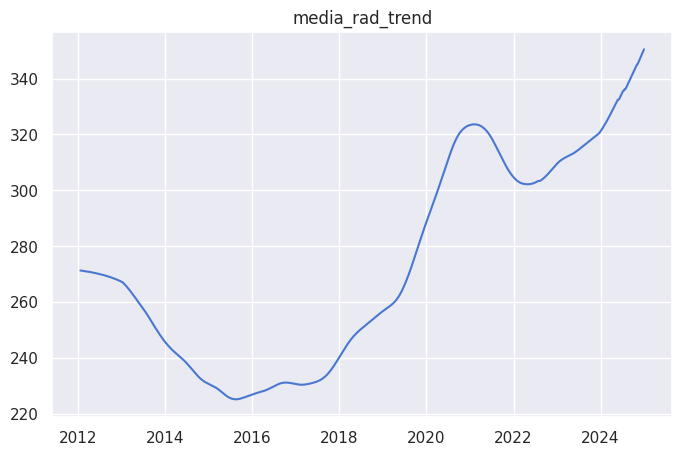

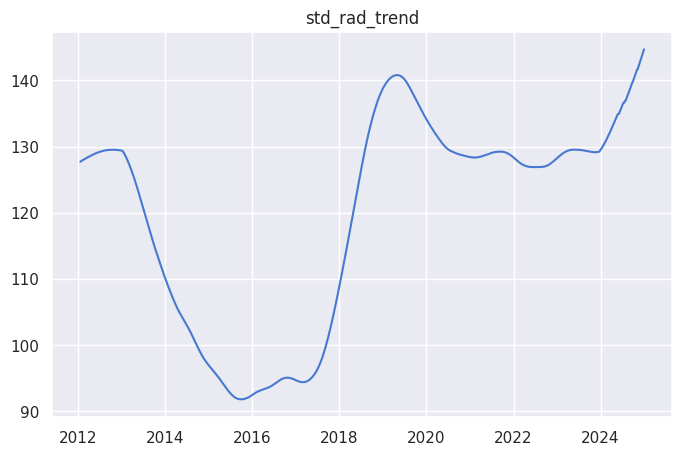

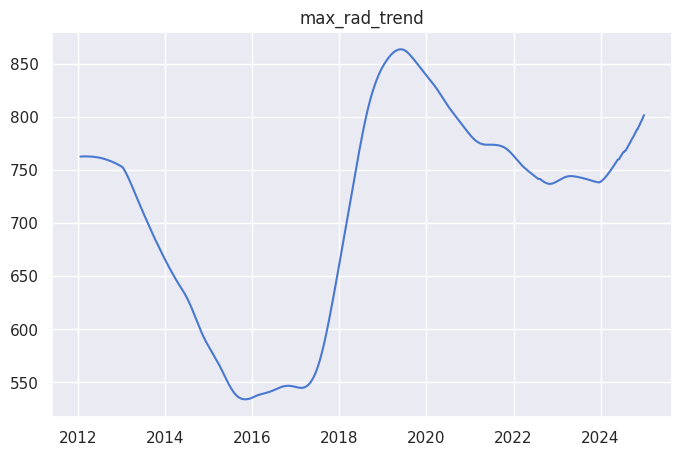

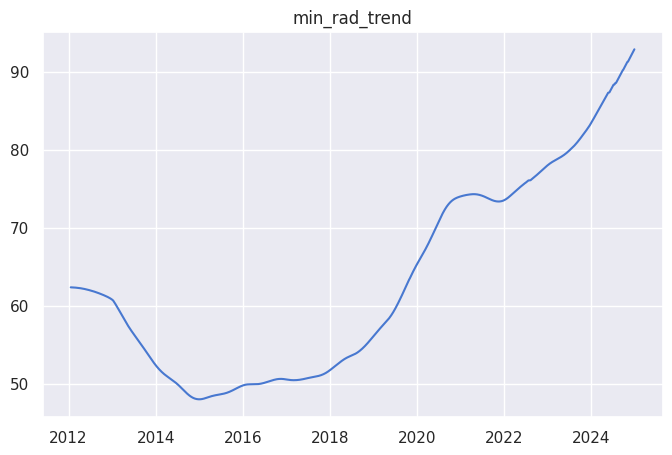

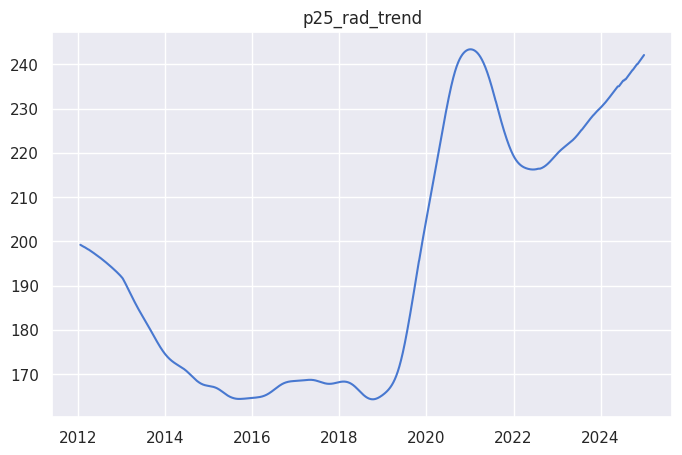

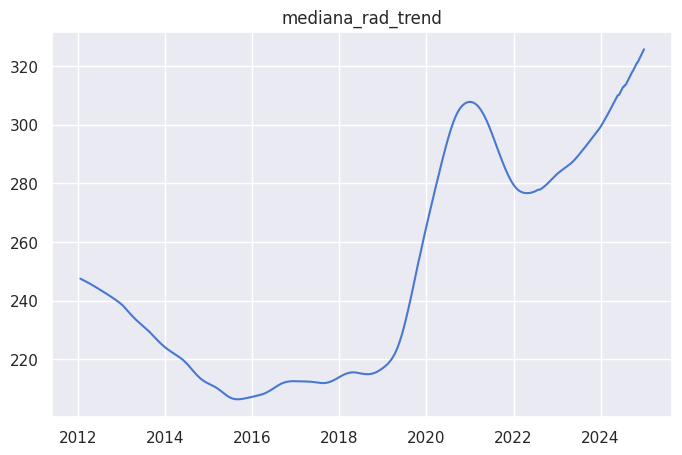

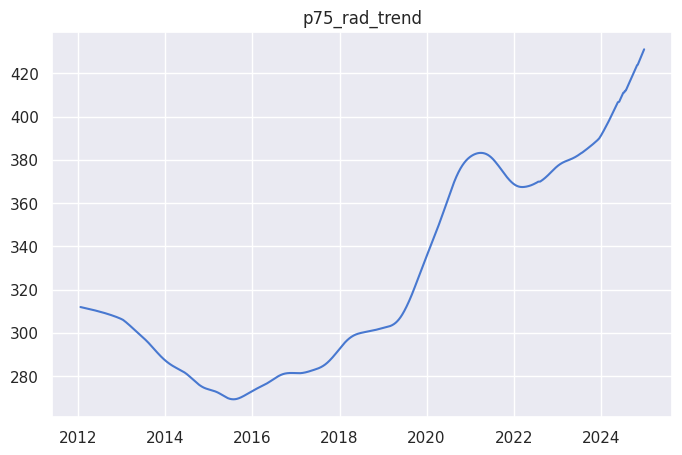

In [ ]:
for feature in df_trend.columns[3:]:
  plt.figure(figsize=(8, 5))
  plt.plot(df_trend.fecha,df_trend[feature])
  plt.title(feature)
  plt.show()

# Generacion de data (union de dataframes)

In [ ]:
mapping = {
    'coyoacán': 'coyoacan',
    'álvaro obregón': 'alvaro obregon',
    'tláhuac': 'tlahuac',
    'benito juárez':'benito juarez',
    'cuauhtémoc': 'cuauhtemoc'
}

In [ ]:
df.fecha.head()

,fecha
340816,2012-01-19
340817,2012-01-20
340818,2012-01-21
340819,2012-01-22
340820,2012-01-23


In [ ]:
# Agregar rad trimestralmente

df = df_trend.copy()

df['fecha'] = pd.to_datetime(df['fecha'])

df['quarter'] = df['fecha'].dt.to_period('Q')

df['fecha_quarter'] = df['quarter'].dt.to_timestamp(how='end').dt.normalize()


radiance_quarterly = (
    df.groupby(['municipio', 'quarter','fecha_quarter'])
      .agg({
          'total_pixeles': 'median',
          'suma_rad_trend': ['sum', 'mean', 'std' ,'median'],
          'media_rad_trend': 'mean',
          'std_rad_trend': 'mean',
          'max_rad_trend': 'max',
          'min_rad_trend': 'min',
          'p25_rad_trend': 'mean',
          'mediana_rad_trend': 'mean',
          'p75_rad_trend': 'mean'
      })
      .reset_index()
)

radiance_quarterly.columns = ['_'.join(col).strip() if isinstance(col, tuple) else col for col in radiance_quarterly.columns.values]

# rename cols
radiance_quarterly = radiance_quarterly.rename(columns={'municipio_': 'municipio', 'quarter_': 'quarter','fecha_quarter_':'fecha'})

In [ ]:
radiance_quarterly.head()

,municipio,quarter,fecha,total_pixeles_median,suma_rad_trend_sum,suma_rad_trend_mean,suma_rad_trend_std,suma_rad_trend_median,media_rad_trend_mean,std_rad_trend_mean,max_rad_trend_max,min_rad_trend_min,p25_rad_trend_mean,mediana_rad_trend_mean,p75_rad_trend_mean
0,oaxaca de juarez,2012Q1,2012-03-31,159.0,2.887180e+06,43092.242058,21.880141,43093.056305,271.020390,128.098132,762.675033,62.266238,198.673765,246.736678,311.499448
1,oaxaca de juarez,2012Q2,2012-06-30,159.0,3.869131e+06,42990.349814,38.054538,42991.775564,270.379559,128.868653,762.602504,61.969251,197.242141,244.869544,310.419135
2,oaxaca de juarez,2012Q3,2012-09-30,159.0,3.940870e+06,42835.540174,53.023466,42838.134126,269.405913,129.397760,761.355393,61.488999,195.350221,242.584830,309.024612
3,oaxaca de juarez,2012Q4,2012-12-31,159.0,3.920935e+06,42618.855717,74.080769,42622.799882,268.043118,129.477754,758.122547,60.779981,193.149894,240.061599,307.305780
4,oaxaca de juarez,2013Q1,2013-03-31,159.0,3.795092e+06,42167.690430,207.133160,42180.303313,265.205600,127.934761,752.969739,58.557165,189.673008,236.671026,304.363901


In [ ]:
df_trend_pib.fecha.head()

,fecha
0,2004-03-31
1,2004-06-30
2,2004-09-30
3,2004-12-31
4,2005-03-31


In [ ]:
# poner los dos en lowercase
radiance_quarterly['municipio'] = radiance_quarterly['municipio'].str.strip().str.lower()
df_trend_pib['municipio'] = df_trend_pib['municipio'].str.strip().str.lower()


radiance_quarterly['fecha'] = pd.to_datetime(radiance_quarterly['fecha'])
df_trend_pib['fecha'] = pd.to_datetime(df_trend_pib['fecha'])


# cambiar nomes de municipio
mapping = {
    'oaxaca de juárez': 'oaxaca de juarez'
}

radiance_quarterly['municipio'] = radiance_quarterly['municipio'].replace(mapping)
df_trend_pib['municipio'] = df_trend_pib['municipio'].replace(mapping)

In [ ]:
df_pib_rad = pd.merge(
    radiance_quarterly,
    df_trend_pib,
    on=['fecha', 'municipio'],
    how='inner'
)

In [ ]:
display(df_pib_rad.head())

,municipio,quarter,fecha,total_pixeles_median,suma_rad_trend_sum,suma_rad_trend_mean,suma_rad_trend_std,suma_rad_trend_median,media_rad_trend_mean,std_rad_trend_mean,max_rad_trend_max,min_rad_trend_min,p25_rad_trend_mean,mediana_rad_trend_mean,p75_rad_trend_mean,entidad_federativa,porc_pob,pibe,pib_mun
0,oaxaca de juarez,2012Q1,2012-03-31,159.0,2.887180e+06,43092.242058,21.880141,43093.056305,271.020390,128.098132,762.675033,62.266238,198.673765,246.736678,311.499448,OAX,0.065572,"239,680.2",15984.537542
1,oaxaca de juarez,2012Q2,2012-06-30,159.0,3.869131e+06,42990.349814,38.054538,42991.775564,270.379559,128.868653,762.602504,61.969251,197.242141,244.869544,310.419135,OAX,0.065572,"246,985.2",16217.769535
2,oaxaca de juarez,2012Q3,2012-09-30,159.0,3.940870e+06,42835.540174,53.023466,42838.134126,269.405913,129.397760,761.355393,61.488999,195.350221,242.584830,309.024612,OAX,0.065572,"254,789.0",16376.090807
3,oaxaca de juarez,2012Q4,2012-12-31,159.0,3.920935e+06,42618.855717,74.080769,42622.799882,268.043118,129.477754,758.122547,60.779981,193.149894,240.061599,307.305780,OAX,0.065572,"259,484.5",16463.612293
4,oaxaca de juarez,2013Q1,2013-03-31,159.0,3.795092e+06,42167.690430,207.133160,42180.303313,265.205600,127.934761,752.969739,58.557165,189.673008,236.671026,304.363901,OAX,0.065572,"245,516.0",16483.367404


In [ ]:
df_pib_rad.to_csv("serie_trimestral_oax_desestacionalizada_agg.csv", index=False, encoding="utf-8")